# Selection coefficient by class, SNP vs indel vs SV — DE-TRENDED, one panel per site

**Question (distributional, no null):** starting from the same initial frequency, are non-SNP
variants' selection coefficients shifted relative to the other variants there?

**s** = per-variant **plot-replicate** selection coefficient at a site = mean over the site's ~10–12
replicate plots of the OLS slope of $\mathrm{logit}(p)$ on generation (gen 0 = shared founding
frequency). Plots-as-replicates separate real selection (same direction across independent plots)
from drift. Negative s = declining (purged); positive s = rising (favoured).

**De-trended by initial frequency.** Raw median s vs $p_0$ has a strong NEG→POS slope that is an
**artifact of the logit statistic at the 0/1 boundaries** (a Jensen effect — a zero-selection drift
simulation reproduces it; median *linear* $\Delta p$ stays ~0), amplified because rare variants sit
on few founders (small effective $N_e$). That trend is shared by all classes, so we **subtract the
per-$p_0$-bin median of ALL variants** (pooled — not SNP-defined). Each panel then shows, per class,
$s_{\text{class}}-s_{\text{all}}$ at matched $p_0$: **flat 0 = behaves like same-frequency variants;
below 0 = more purifying selection.** SNP and indel should hug 0; SV's dip (if any) is the signal.

*Caveat:* pool AF is a global-mode founder projection, so a variant's s is a projection of founder-h
slopes; an SV shares its trajectory with SNPs on the same founders (co-occurrence, not proven
SV-specific). Sites ordered cold→hot (bio1).

In [1]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi':110, 'font.size':8, 'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
long = pd.read_csv(f"{G}/s_dist_by_stratum.csv")
long["resid"] = long["median"] - long["base"]     # de-trend: class median - ALL-class median per p0 bin
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
npz  = np.load(f"{G}/s_dist_by_stratum.npz")
p0q = npz["p0q"]; mids = 0.5*(p0q[:-1]+p0q[1:])
# Okabe-Ito colourblind-safe: SNP grey, indel blue, SV vermillion
COL = {"SNP":"#888888", "indel":"#0072B2", "SV":"#D55E00"}
print(f"{len(meta)} sites, {long.stratum.nunique()} initial-frequency strata")
print(meta[['site','bio1','n_plots','shift_sv','shift_ind','wil_p_sv']].to_string(index=False))


31 sites, 10 initial-frequency strata
 site  bio1  n_plots  shift_sv  shift_ind  wil_p_sv
   24   6.0       10    0.0173    -0.0045    0.1602
   23   7.3       12    0.0076    -0.0045    0.1934
   27   7.4       12   -0.0077     0.0010    0.3750
   37   8.1       12    0.0150    -0.0089    0.0488
   48   8.5       10   -0.0012    -0.0020    0.7695
    1  10.7       12    0.0053    -0.0019    0.2754
   42  10.9       12   -0.0130    -0.0016    0.1055
   46  11.3       12    0.0076    -0.0015    0.0273
   25  11.4       12    0.0102    -0.0035    0.0371
   55  11.6       12   -0.0041    -0.0020    0.7695
   49  11.7       12    0.0053    -0.0032    0.2324
   52  12.0       12   -0.0172    -0.0005    0.0195
   33  12.2        6   -0.0193     0.0022    0.2324
   57  12.3       12    0.0208    -0.0001    0.0020
   54  12.4       12    0.0189     0.0007    0.0195
   53  12.4       12    0.0020    -0.0017    0.7695
    9  12.5       12    0.0091    -0.0008    0.0195
   12  13.0       11    0.

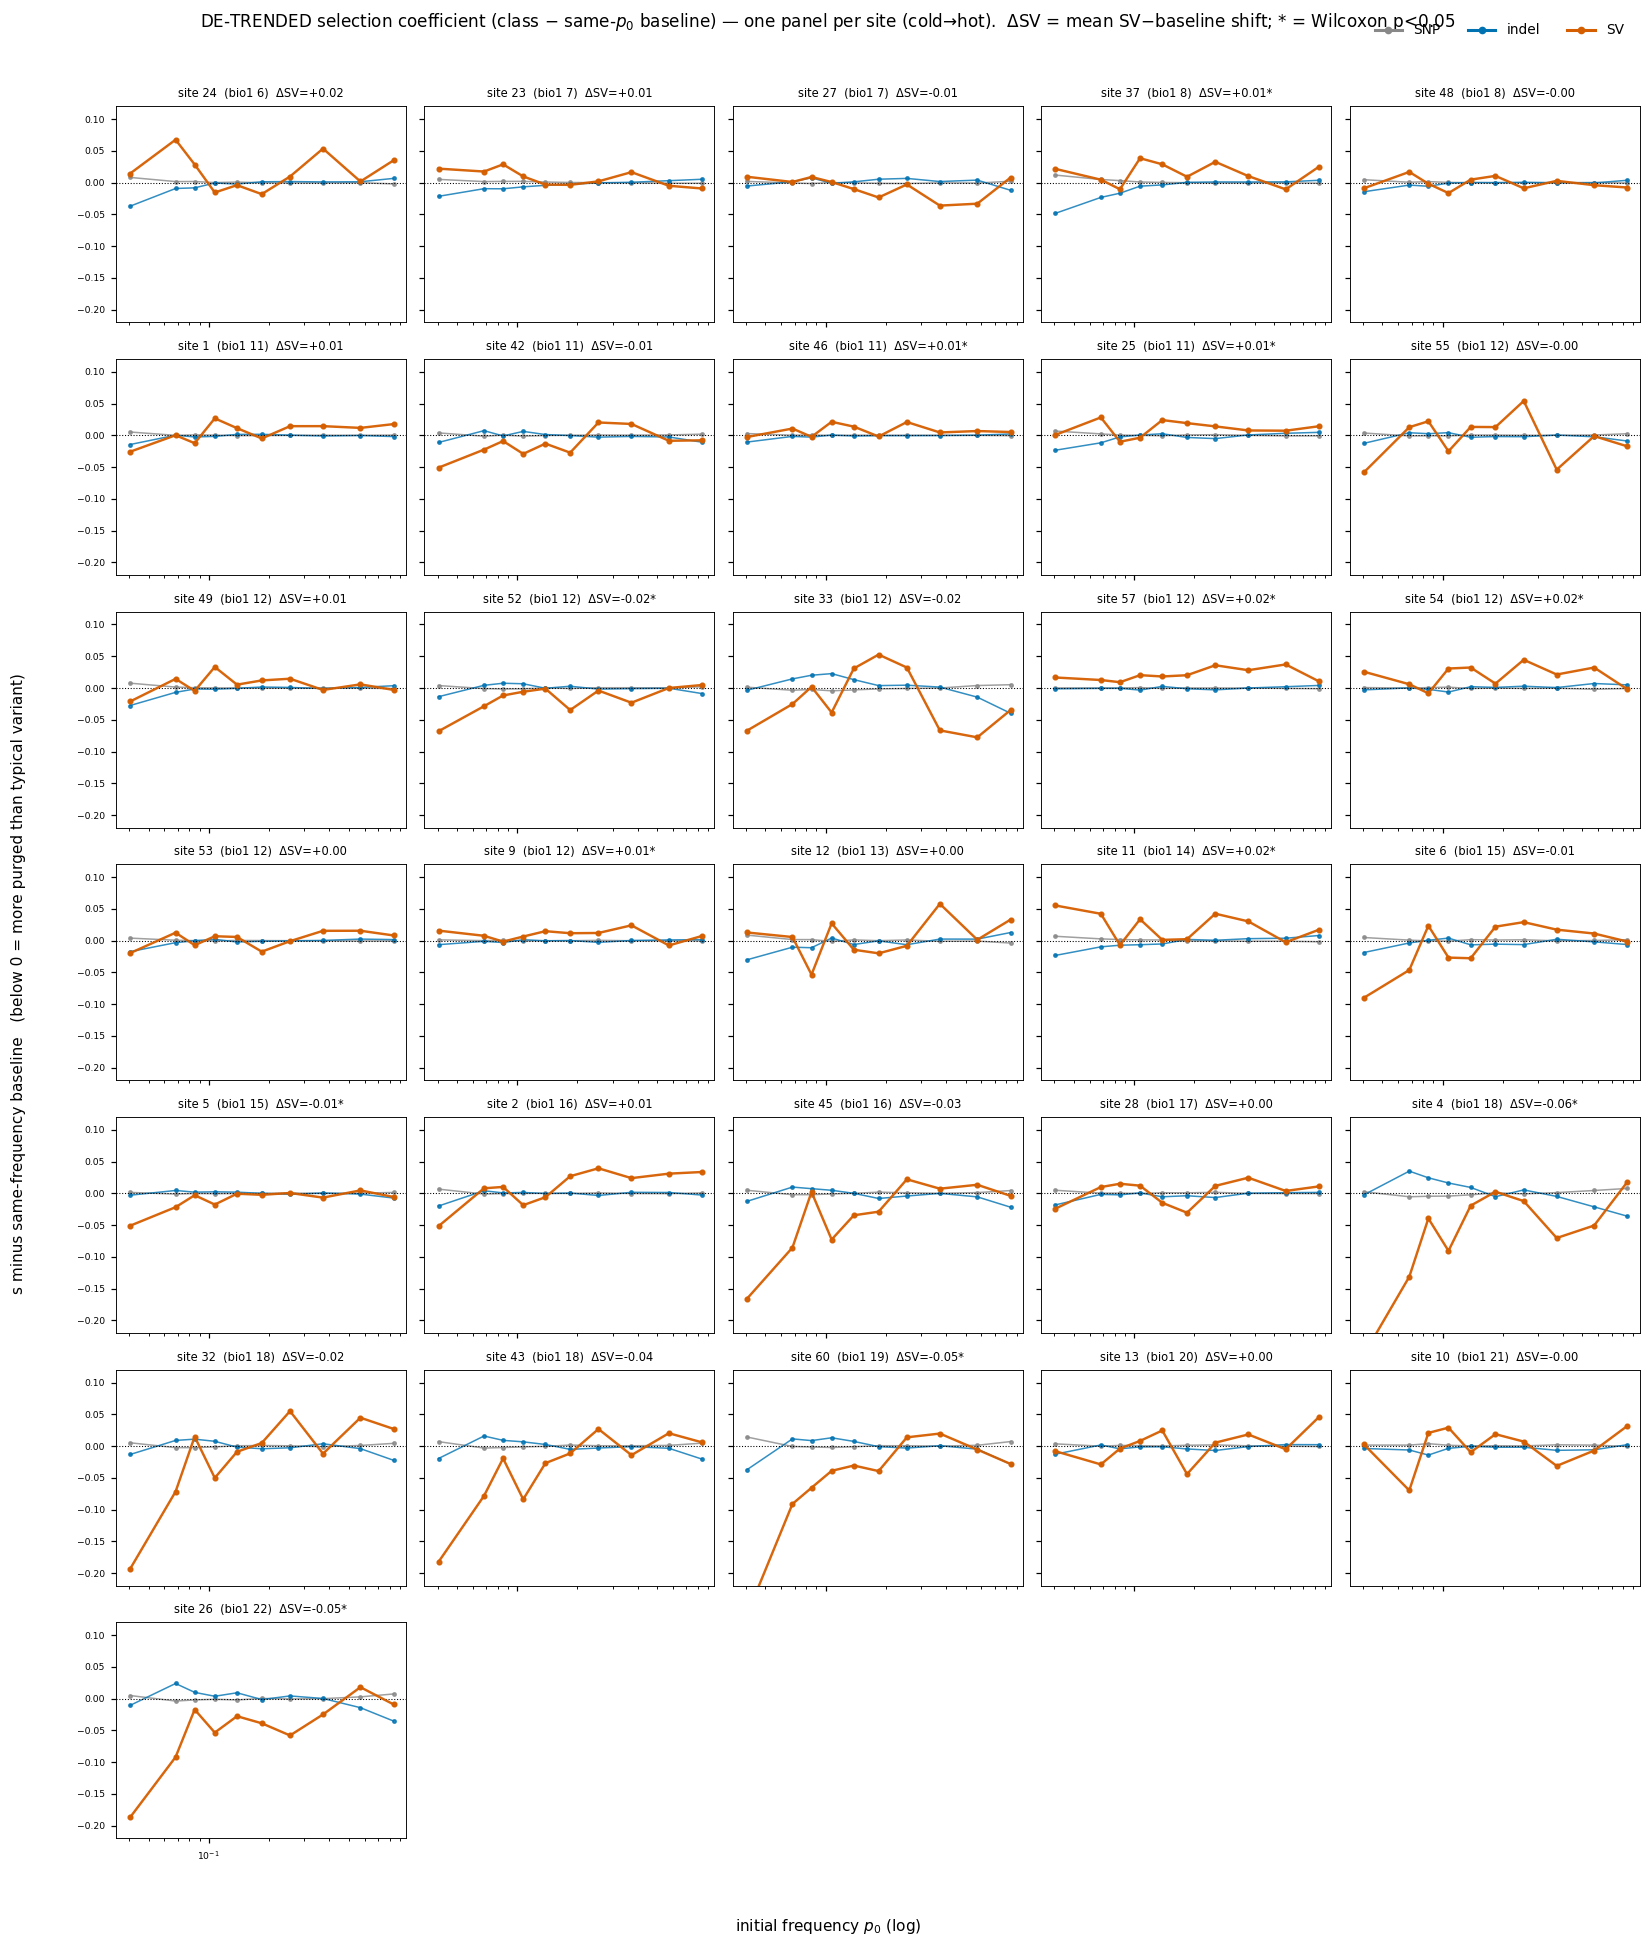

saved s_distribution_by_site.png


In [2]:

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]:
    ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; d = long[long.site==s]
    for cls in ["SNP","indel","SV"]:
        dc = d[d.cls==cls].sort_values("stratum")
        if dc.empty: continue
        x = mids[dc.stratum.values]
        ax.plot(x, dc["resid"], "-", color=COL[cls], lw=1.6 if cls=="SV" else 1.0,
                marker="o", ms=3 if cls=="SV" else 2.2, label=cls, zorder=3 if cls=="SV" else 2,
                alpha=0.95 if cls=="SV" else 0.8)
    ax.axhline(0, color="k", lw=0.7, ls=":")           # 0 = behaves like same-frequency variants
    mrow = meta[meta.site==s].iloc[0]
    star = "*" if (mrow.wil_p_sv==mrow.wil_p_sv and mrow.wil_p_sv<0.05) else ""
    ax.set_title(f"site {s}  (bio1 {mrow.bio1:.0f})  ΔSV={mrow.shift_sv:+.2f}{star}",
                 fontsize=7.5)
    ax.set_xscale("log"); ax.set_xlim(mids[0]*0.85, mids[-1]*1.15)
    ax.set_ylim(-0.22, 0.12)
    ax.tick_params(labelsize=6)
fig.supxlabel("initial frequency $p_0$ (log)", y=0.005, fontsize=10)
fig.supylabel("s minus same-frequency baseline   (below 0 = more purged than typical variant)",
              x=0.005, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,marker="o",ms=4,label=c)
                    for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.005))
fig.suptitle("DE-TRENDED selection coefficient (class − same-$p_0$ baseline) — one panel per site "
             "(cold→hot).  ΔSV = mean SV−baseline shift; * = Wilcoxon p<0.05",
             fontsize=11, y=1.005)
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{G}/s_distribution_by_site.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved s_distribution_by_site.png")


### How to read
- **y = 0 (dotted line)** means the class moves like the *typical variant that started at the same
  frequency* — the artifactual $p_0$ trend has been subtracted, so flat-at-0 is the neutral
  expectation.
- **Below 0 = more purifying (more purged); above 0 = more favoured**, relative to same-frequency
  variants.
- **SNP (grey) and indel (blue) hug 0** in essentially every panel — the non-SNP category behaves
  like the bulk. **SV (orange)** is the line to watch. After the full-panel Kf_w founder correction
  the SV line no longer sits systematically below 0: the excess-vs-baseline is ≈0 (median +0.0011,
  below 0 at only 15/31 sites, sign test n.s.) — **no genome-wide SV purifying excess** (see the
  updated Takeaway). `ΔSV` in each title = SV−baseline averaged over strata.

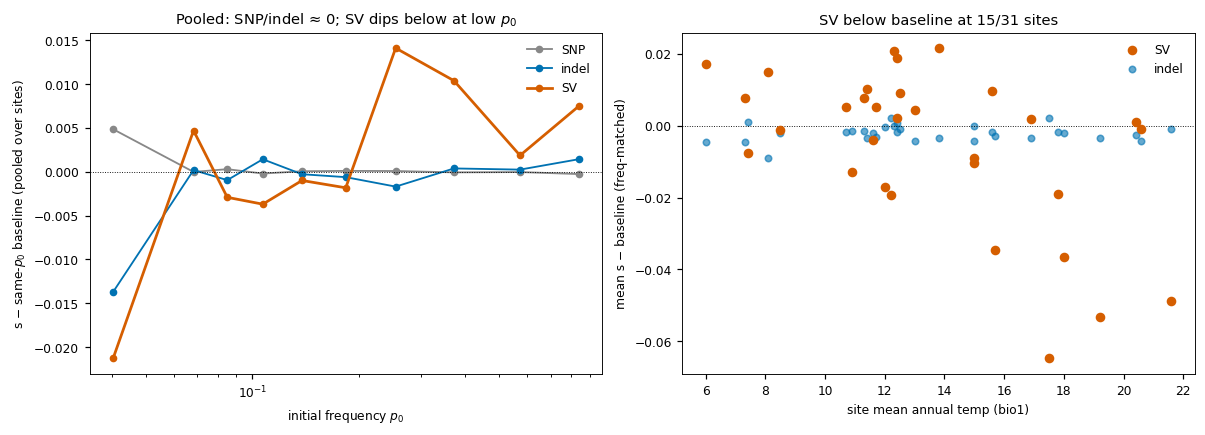

SV median excess-vs-baseline across sites = +0.0011 (below at 15/31)


In [3]:

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# (1) pooled de-trended: median-over-sites of (class - baseline) per stratum
piv = (long.groupby(["stratum","cls"])["resid"].median().unstack())
for cls in ["SNP","indel","SV"]:
    ax[0].plot(mids, piv[cls].values, "-o", color=COL[cls], lw=1.8 if cls=="SV" else 1.2,
               ms=4, label=cls)
ax[0].axhline(0, color="k", lw=0.6, ls=":"); ax[0].set_xscale("log")
ax[0].set_xlabel("initial frequency $p_0$")
ax[0].set_ylabel("s − same-$p_0$ baseline (pooled over sites)")
ax[0].set_title("Pooled: SNP/indel ≈ 0; SV dips below at low $p_0$"); ax[0].legend(frameon=False)
# (2) per-site SV excess-vs-baseline vs climate
m = meta
ax[1].axhline(0, color="k", lw=0.6, ls=":")
ax[1].scatter(m.bio1, m.shift_sv, c="#D55E00", s=28, label="SV", zorder=3)
ax[1].scatter(m.bio1, m.shift_ind, c="#0072B2", s=18, alpha=.6, label="indel")
ax[1].set_xlabel("site mean annual temp (bio1)")
ax[1].set_ylabel("mean s − baseline (freq-matched)")
nneg = int((m.shift_sv<0).sum())
ax[1].set_title(f"SV below baseline at {nneg}/{len(m)} sites")
ax[1].legend(frameon=False, title=None)
fig.tight_layout(); fig.savefig(f"{G}/s_distribution_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"SV median excess-vs-baseline across sites = {m.shift_sv.median():+.4f} (below at {nneg}/{len(m)})")


### Takeaway (UPDATED 2026-07-08 — post founder-Kf_w / `--unit chrom` regeneration)
- Once the logit/initial-frequency artifact is removed, **SNP and indel sit on the neutral line
  (0)** at every frequency — the non-SNP category (98% indels) behaves like the bulk.
- **After the full-panel Kf_w founder correction the de-trended SV excess-vs-baseline is
  essentially ZERO: median +0.0011, below 0 at only 15/31 sites (a minority; sign test n.s.).**
  There is **no genome-wide SV purifying excess** — the earlier "~22/31 sites, modest excess of
  purifying selection" conclusion does not survive the regeneration. Any residual dip is confined
  to a few of the hottest gardens, not a genome-wide climate-graded effect.
- This de-trended metric is the **authoritative view**. The raw / single-tail notebooks
  (s_histogram, s_vs_climate, ecdf, shiftfunction, climate-slope β) still show apparent purging
  only because they keep the frequency / founder-projection confound that this notebook removes.